In [ ]:
#Global Tech Job Market and Career Trajectories (2019-2026)
# Exploratory Data Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [ ]:
df = pd.read_csv('/content/tech_job_market_2019_2026.csv')
df

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114995,JOB012896,EmberReach Technologies,FAANG-tier,HealthTech,57977,UK,Software Engineer,Lead,7,16,...,2025-11-14 00:00:00,2025-12-21,Filled,45.0,6.0,1.0,1.0,215300.0,254300.0,Yes
114996,JOB060961,AstraSuite,MNC,HealthTech,163658,Brazil,Data Scientist,Senior,4,10,...,NaN,NaN,Open,57.0,4.0,1.0,0.0,87500.0,113500.0,0
114997,JOB006013,MeridianLogix Co,Startup,Fintech,473,Canada,Analytics Engineer,Mid,2,6,...,2024-02-09 00:00:00,NaN,Cancelled,141.0,3.0,1.0,1.0,126000.0,156400.0,N
114998,JOB063108,WrenCampus,Mid-size,Cybersecurity,5425,India,Technical Program Manager,Senior,5,8,...,2024-09-04 00:00:00,NaN,Open,78.0,4.0,1.0,1.0,156000.0,174100.0,No


In [ ]:
# Structural checks
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [ ]:
df.tail()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
114995,JOB012896,EmberReach Technologies,FAANG-tier,HealthTech,57977,UK,Software Engineer,Lead,7,16,...,2025-11-14 00:00:00,2025-12-21,Filled,45.0,6.0,1.0,1.0,215300.0,254300.0,Yes
114996,JOB060961,AstraSuite,MNC,HealthTech,163658,Brazil,Data Scientist,Senior,4,10,...,NaN,NaN,Open,57.0,4.0,1.0,0.0,87500.0,113500.0,0
114997,JOB006013,MeridianLogix Co,Startup,Fintech,473,Canada,Analytics Engineer,Mid,2,6,...,2024-02-09 00:00:00,NaN,Cancelled,141.0,3.0,1.0,1.0,126000.0,156400.0,N
114998,JOB063108,WrenCampus,Mid-size,Cybersecurity,5425,India,Technical Program Manager,Senior,5,8,...,2024-09-04 00:00:00,NaN,Open,78.0,4.0,1.0,1.0,156000.0,174100.0,No
114999,JOB006559,QuantumBuzz Technologies,MNC,SaaS,108163,UK,Backend Engineer,Mid,3,6,...,2021-01-02 00:00:00,2021-02-16,Filled,48.0,4.0,1.0,1.0,120400.0,147000.0,N


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  object 
 1   company_name                  115000 non-null  object 
 2   company_type                  115000 non-null  object 
 3   sector                        115000 non-null  object 
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  object 
 6   job_role                      115000 non-null  object 
 7   seniority_level               115000 non-null  object 
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  object 
 11  primary_programming_language  92525 non-null   object 
 12  work_mode                     115000 non-nul

In [ ]:
df.shape

(115000, 28)

In [ ]:
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag'],
      dtype='object')

In [ ]:
df.dtypes

,0
job_id,object
company_name,object
company_type,object
sector,object
company_size_employees,int64
hq_country,object
job_role,object
seniority_level,object
years_experience_min,int64
years_experience_max,int64


In [ ]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [ ]:
# Missing Values
df.isnull().sum()


,0
job_id,0
company_name,0
company_type,0
sector,0
company_size_employees,0
hq_country,0
job_role,0
seniority_level,0
years_experience_min,0
years_experience_max,0


In [ ]:
# Percentage of missing value
(df.isnull().sum()/len(df))*100

,0
job_id,0.000000
company_name,0.000000
company_type,0.000000
sector,0.000000
company_size_employees,0.000000
hq_country,0.000000
job_role,0.000000
seniority_level,0.000000
years_experience_min,0.000000
years_experience_max,0.000000


In [ ]:
missing = df.isnull().sum()
a=missing[missing>0]
a

,0
primary_programming_language,22475
job_location_city,25107
application_deadline,5757
date_position_filled,25781
number_of_applicants,1110
number_of_interview_rounds,436
offers_extended,330
offers_accepted,330
salary_min_usd,3318
salary_max_usd,3318


Text(0, 0.5, 'Missing value')

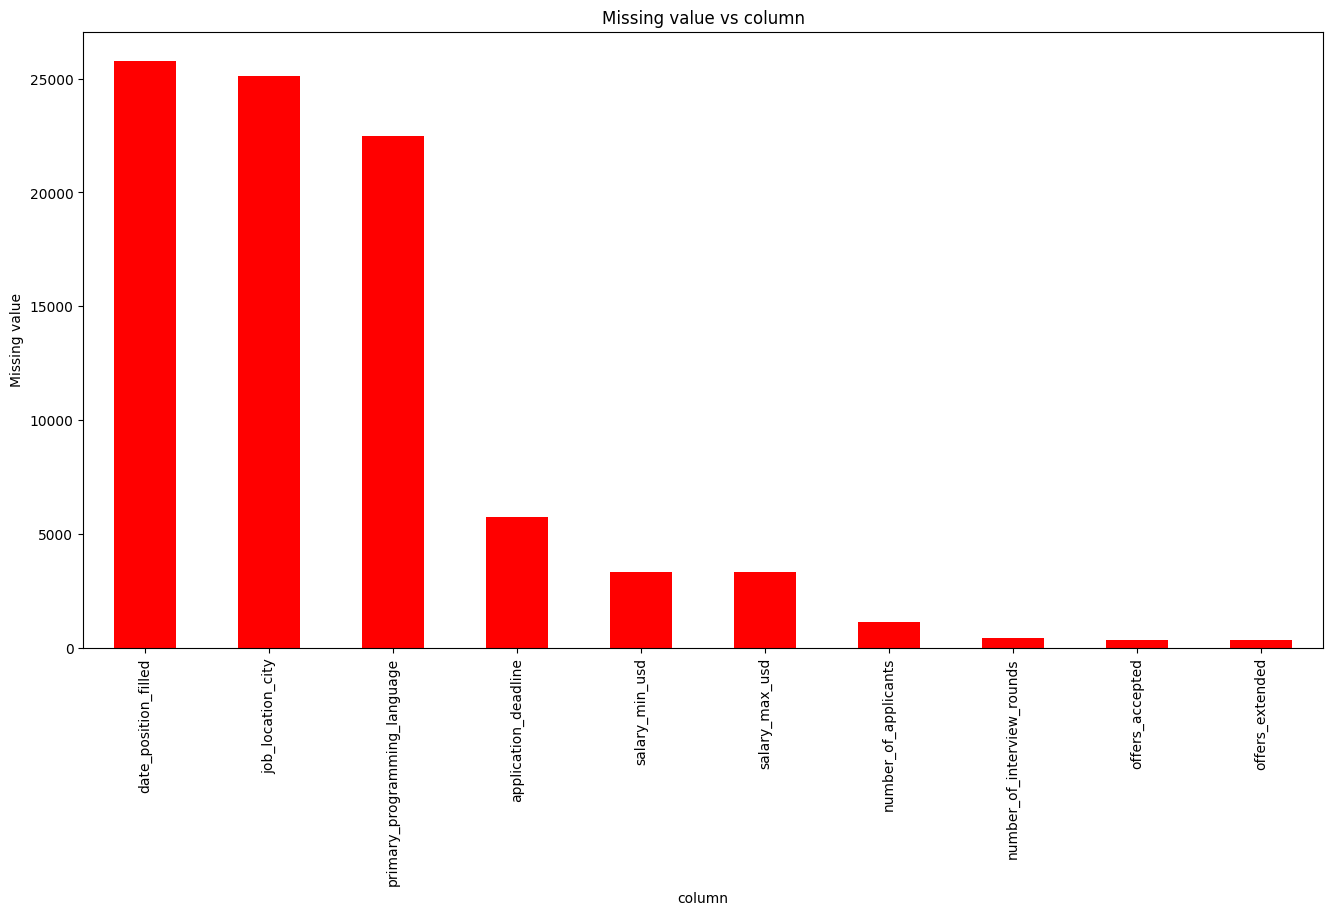

In [ ]:
# Graph
a.sort_values(ascending=False).plot(kind='bar',color='red',figsize=(16,8))
plt.title('Missing value vs column')
plt.xlabel('column')
plt.ylabel('Missing value')


In [ ]:
df.isnull().sum().sum()

np.int64(87962)

In [ ]:
# Duplicate Analysis
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
114995,False
114996,False
114997,False
114998,False


In [ ]:
df.duplicated().sum()

np.int64(1193)

In [ ]:
df[df.duplicated()]

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
1584,JOB002656,DriftGame Co,MNC,EdTech,156326,USA,Data Scientist,Senior,6,8,...,2024-02-19 00:00:00,2024-02-07,Filled,99.0,5.0,1.0,1.0,153600.0,188500.0,False
2216,JOB000563,NexusCompute,FAANG-tier,Crypto/Web3,142214,Brazil,DevOps Engineer,Senior,4,10,...,2019-08-31 00:00:00,2019-09-22,Filled,90.0,4.0,1.0,1.0,185600.0,247000.0,1
2969,JOB073226,BeaconPixel,MNC,Cloud/Infra,74335,Germany,Backend Engineer,Mid,1,4,...,2022-09-14 00:00:00,NaN,Cancelled,244.0,2.0,0.0,0.0,139200.0,168900.0,No
3897,JOB022039,BeaconStack Co,MNC,AI/ML,277054,USA,Infrastructure Engineer,Entry,0,2,...,2026-01-24 00:00:00,2026-03-21,Filled,123.0,3.0,1.0,1.0,99300.0,119700.0,N
4327,JOB006733,SummitShield Co,Mid-size,E-commerce,5508,UK,Platform Engineer,Senior,5,11,...,2021-03-26 00:00:00,2021-05-07,Filled,54.0,4.0,1.0,1.0,92900.0,120300.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114639,JOB110813,BeaconStack Co,MNC,AI/ML,245179,USA,Mobile Engineer (Android),Entry,0,2,...,2019-05-09 00:00:00,NaN,Cancelled,249.0,3.0,0.0,0.0,NaN,NaN,False
114824,JOB100893,AnchorBuzz Labs,MNC,HealthTech,157695,USA,QA Engineer,Intern,0,1,...,2023-04-30 00:00:00,2023-05-11,Filled,322.0,3.0,1.0,1.0,27700.0,36300.0,False
114866,JOB110283,CobaltWealth,MNC,HealthTech,136976,Germany,Embedded Systems Engineer,Senior,5,8,...,NaN,2021-05-15,Filled,77.0,5.0,1.0,1.0,-1,-1,False
114871,JOB035395,AetherAI Co,MNC,AI/ML,208677,UK,Infrastructure Engineer,Lead,7,15,...,2020-08-06 00:00:00,2020-09-11,Filled,30.0,6.0,1.0,1.0,296800.0,363500.0,No


In [ ]:
# Numerical columns
num_col=df.select_dtypes(include=np.number).columns
num_col

Index(['company_size_employees', 'years_experience_min',
       'years_experience_max', 'number_of_applicants',
       'number_of_interview_rounds', 'offers_extended', 'offers_accepted'],
      dtype='object')

In [ ]:
df[num_col].describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [ ]:
# Categorical consistency
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(col)
    print("Unique:", df[col].nunique())
    print(df[col].value_counts().head(15))

job_id
Unique: 113000
job_id
JOB001361    3
JOB051125    3
JOB055551    3
JOB004262    3
JOB007136    3
JOB054307    3
JOB080699    3
JOB088269    3
JOB086783    2
JOB011000    2
JOB036102    2
JOB086716    2
JOB016573    2
JOB080687    2
JOB089465    2
Name: count, dtype: int64
company_name
Unique: 898
company_name
NexusShield                 3265
MeridianToken               3201
RidgeFreight Labs           3106
SpireCloud                  3030
AetherAI Co                 2746
EchoFreight Systems         2666
BeaconStack Co              2536
AnchorBuzz Labs             2522
DriftGame Co                2438
MeridianShield Labs         2401
OrbitNeural Technologies    2273
NovaFleet                   2229
FusionTrade                 2223
NexusCompute                2220
AstraSuite                  2092
Name: count, dtype: int64
company_type
Unique: 5
company_type
MNC           56053
Mid-size      20305
Unicorn       16078
FAANG-tier    15963
Startup        6601
Name: count, dtype: int64

In [ ]:
# logical and referencial checks
# Experience
df[df['years_experience_max'] < df['years_experience_min']]

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
131,JOB031986,DriftSkill Inc,MNC,E-commerce,126266,Canada,Mobile Engineer (Android),Entry,4,1,...,2024-12-17 00:00:00,NaN,Cancelled,186.0,2.0,1.0,1.0,58600.0,66200.0,No
133,JOB089059,CatalystHub Co,Unicorn,AI/ML,3541,Ireland,Backend Engineer,Mid,7,2,...,2024-09-06 00:00:00,2024-08-16,Filled,123.0,3.0,1.0,1.0,137000.0,156600.0,N
679,JOB101867,NimbusGame Technologies,Mid-size,EdTech,4008,Germany,Site Reliability Engineer,Senior,8,4,...,2022-03-28 00:00:00,2022-03-24,Filled,28.0,5.0,1.0,1.0,149600.0,187300.0,No
1943,JOB011486,FusionTrade,MNC,Fintech,165215,UAE,Mobile Engineer (Android),Mid,7,2,...,2026-02-12 00:00:00,2026-03-12,Filled,91.0,2.0,1.0,1.0,Not Disclosed,Not Disclosed,False
2301,JOB101144,FusionTrade,MNC,Fintech,159001,UAE,Full Stack Engineer,Mid,6,2,...,2024-05-21 00:00:00,2024-05-26,Filled,247.0,4.0,4.0,3.0,98600.0,123100.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113800,JOB018427,VertexBlock Inc,MNC,Gaming,108196,India,Embedded Systems Engineer,Senior,10,6,...,2024-07-07 00:00:00,2024-08-23,Filled,79.0,5.0,1.0,1.0,182400.0,203900.0,False
114117,JOB069657,TideSentinel Technologies,Unicorn,HealthTech,13181,UK,Analytics Engineer,Senior,8,6,...,2025-03-26 00:00:00,2025-04-17,Filled,54.0,5.0,1.0,1.0,219000.0,285100.0,N
114292,JOB023878,AetherAI Co,MNC,AI/ML,243023,UK,Embedded Systems Engineer,Entry,4,0,...,2025-04-19 00:00:00,NaN,Withdrawn,93.0,2.0,0.0,0.0,96600.0,128300.0,Yes
114629,JOB085791,MeridianToken,MNC,EdTech,358354,USA,QA Engineer,Entry,3,0,...,2020-04-07 00:00:00,2020-05-28,Filled,234.0,1.0,1.0,1.0,76700.0,102600.0,False


In [ ]:
# salary
df[df['salary_max_usd'] < df['salary_min_usd']]

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
7,JOB057551,EchoCortex Co,MNC,Cybersecurity,128882,USA,Embedded Systems Engineer,Entry,0,4,...,2024-05-25 00:00:00,2024-05-29,Filled,258.0,3.0,1.0,1.0,131100.0,103900.0,N
14,JOB015507,QuantumBuzz Technologies,MNC,SaaS,116690,UK,Backend Engineer,Mid,1,6,...,2019-01-22 00:00:00,2019-04-23,Filled,126.0,3.0,1.0,1.0,82600.0,106100.0,0
18,JOB014227,LumenArcade Technologies,MNC,Logistics,123108,France,Platform Engineer,Senior,5,9,...,2023-05-23 00:00:00,2023-06-24,Filled,44.0,4.0,1.0,1.0,96900.0,117400.0,0
48,JOB101281,SolaceShop Labs,Mid-size,EdTech,4417,India,Data Analyst,Senior,6,8,...,2025-02-25 00:00:00,2025-02-10,Filled,67.0,3.0,1.0,1.0,93400.0,125000.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114978,JOB059417,DriftSkill Inc,MNC,E-commerce,118246,Canada,Platform Engineer,Mid,3,6,...,2026-06-16 00:00:00,NaN,Cancelled,52.0,4.0,1.0,1.0,96400.0,128900.0,0
114982,JOB006051,LumenArcade Technologies,MNC,Logistics,139163,France,Product Manager,Mid,2,5,...,NaN,2025-12-12,Filled,60.0,4.0,1.0,1.0,97100.0,118200.0,0
114984,JOB112680,RuneCompute,Mid-size,AI/ML,4200,Netherlands,Mobile Engineer (Android),Mid,1,7,...,2026-02-16 00:00:00,2026-02-26,Filled,186.0,3.0,1.0,1.0,84500.0,111500.0,No
114988,JOB046390,DriftGame,Unicorn,HealthTech,13786,India,Product Designer,Entry,1,3,...,2022-04-02 00:00:00,2022-03-04,Filled,101.0,2.0,4.0,3.0,96300.0,120600.0,True


In [ ]:
# offers
df[df['offers_accepted'] > df['offers_extended']]

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
6,JOB080320,SpireCloud,MNC,Fintech,369939,USA,UI Designer,Entry,0,1,...,2022-06-16 00:00:00,2022-06-09,Filled,281.0,1.0,1.0,3.0,87400.0,98100.0,False
122,JOB015271,PinnacleLedger Labs,FAANG-tier,Social/AdTech,91663,USA,Embedded Systems Engineer,Mid,2,5,...,2021-03-02 00:00:00,2021-03-29,Filled,160.0,3.0,7.0,9.0,178100.0,223900.0,0
268,JOB080660,NimbusFlow,FAANG-tier,Crypto/Web3,85062,UK,Mobile Engineer (Android),Senior,5,11,...,2025-03-23 00:00:00,2025-04-10,Filled,122.0,6.0,7.0,9.0,178500.0,197900.0,No
849,JOB084218,DriftNeural Systems,Mid-size,E-commerce,4709,Singapore,Application Security Engineer,Intern,0,2,...,2025-04-19 00:00:00,NaN,Cancelled,174.0,1.0,1.0,3.0,20100.0,27100.0,N
976,JOB048731,VertexBlock Inc,MNC,Gaming,90434,India,Penetration Tester,Mid,3,4,...,2026-03-15 00:00:00,2026-04-24,Filled,128.0,3.0,1.0,3.0,100700.0,115400.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114530,JOB066528,BeaconPixel,MNC,Cloud/Infra,66559,Germany,Associate Product Manager,Mid,2,6,...,2024-06-16 00:00:00,2024-06-13,Filled,84.0,4.0,1.0,3.0,103400.0,119700.0,No
114618,JOB063410,MarrowChain Systems,Unicorn,E-commerce,9008,Brazil,Product Manager,Lead,8,16,...,2026-03-06 00:00:00,2026-03-19,Filled,31.0,6.0,1.0,3.0,201500.0,253800.0,False
114720,JOB095411,AetherAI Co,MNC,AI/ML,236524,UK,Mobile Engineer (Android),Principal,12,22,...,2026-03-31 00:00:00,NaN,Open,16.0,5.0,6.0,7.0,211500.0,269400.0,0
114880,JOB033223,OnyxBuzz Inc,Unicorn,Social/AdTech,12011,USA,Embedded Systems Engineer,Mid,3,4,...,2026-06-11 00:00:00,2026-05-26,Filled,130.0,2.0,1.0,3.0,140100.0,161500.0,N


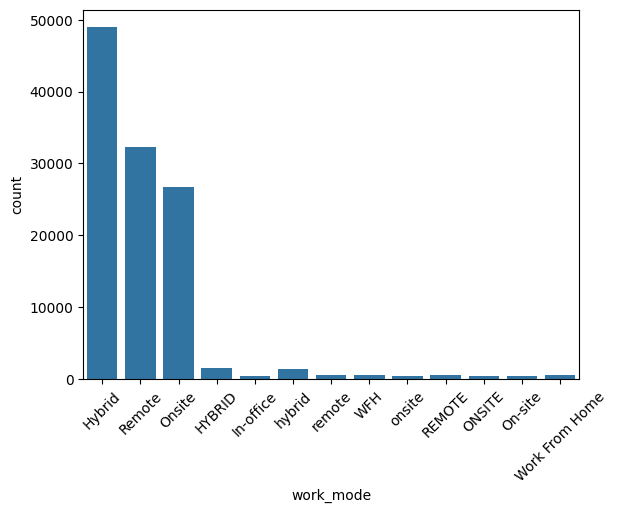

In [ ]:

#Univariate
sns.countplot(data=df, x='work_mode')
plt.xticks(rotation=45)
plt.show()

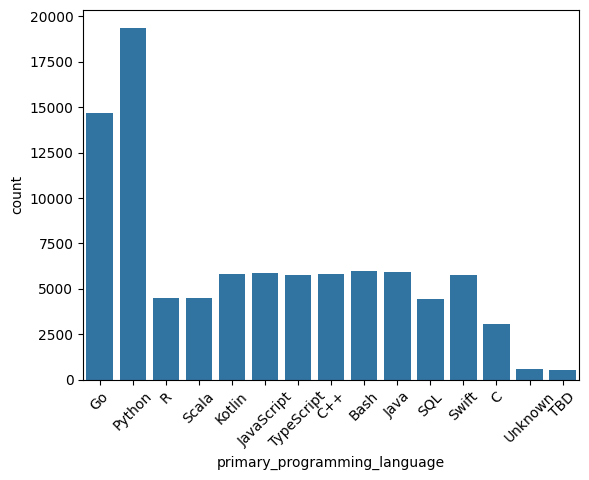

In [ ]:
sns.countplot(data=df, x='primary_programming_language')
plt.xticks(rotation=45)
plt.show()

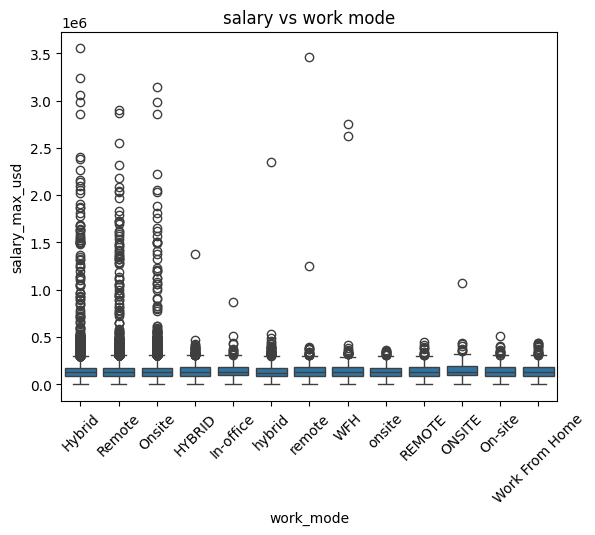

In [ ]:
# Bivariate analysis
df['salary_max_usd']=pd.to_numeric(df['salary_max_usd'],errors='coerce')
sns.boxplot(data=df,x='work_mode',y='salary_max_usd')
plt.xticks(rotation=45)
plt.title('salary vs work mode')
plt.show()



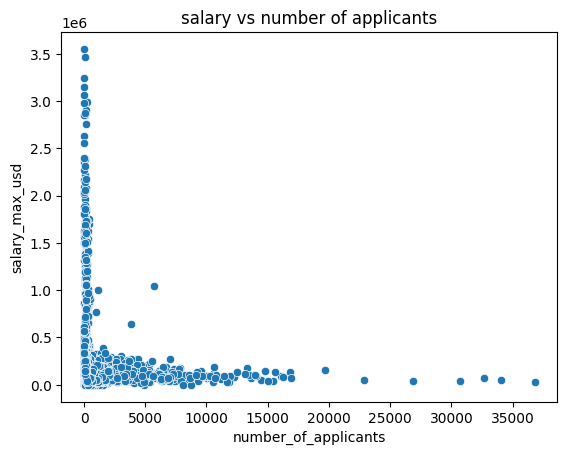

In [ ]:

sns.scatterplot(data=df,x='number_of_applicants',y='salary_max_usd')
plt.title('salary vs number of applicants')
plt.show()

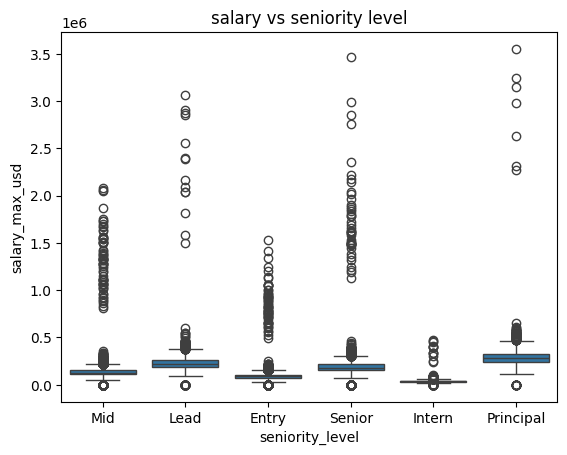

In [ ]:
sns.boxplot(data=df,x='seniority_level',y='salary_max_usd')
plt.title('salary vs seniority level')
plt.show()

In [ ]:
# convert into numbers
df['salary_min_usd']=pd.to_numeric(df['salary_min_usd'],errors='coerce')
df['salary_max_usd']=pd.to_numeric(df['salary_max_usd'],errors='coerce')

In [ ]:
df[['salary_min_usd', 'salary_max_usd']].isnull().sum()

,0
salary_min_usd,5388
salary_max_usd,4004


Missing rows ko remove karna

In [ ]:
df = df.dropna(subset=['salary_min_usd', 'salary_max_usd'])

In [ ]:
df['average_salary'] = (df['salary_min_usd'] + df['salary_max_usd']) / 2

/tmp/ipykernel_33629/4058767571.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['average_salary'] = (df['salary_min_usd'] + df['salary_max_usd']) / 2


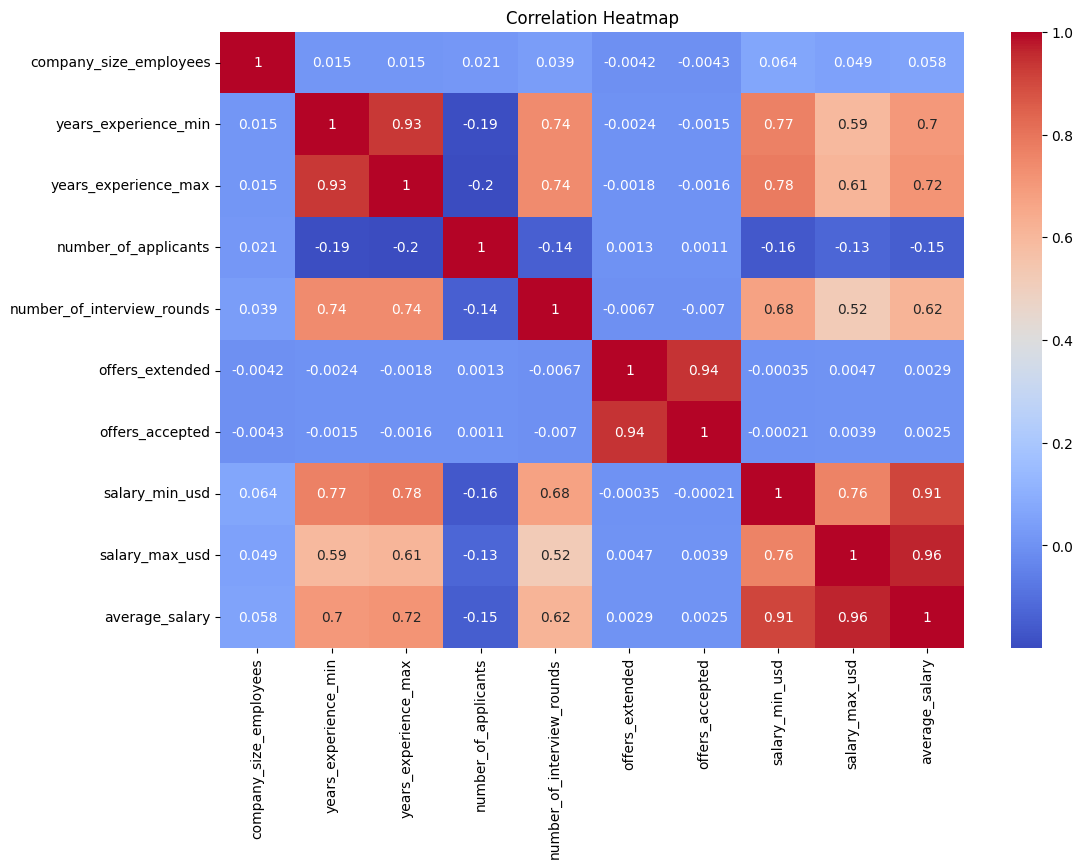

In [ ]:
# Correlation Analysis
numeric_cols = df.select_dtypes(include='number')
correlation = numeric_cols.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Task 2: supervised Learning Algorithms

#Case 1: Salary Prediction- Regression
The objective of this case is to predict a candidate's expected salary based on job posting attributes using Linear Regression.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag,average_salary
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1.0,-1.0,N,-1.0
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0,256750.0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes,100150.0
5,JOB099770,QuantumBuzz Technologies,MNC,SaaS,86535,UK,Data Engineer,Intern,1,1,...,2025-09-09,Filled,58.0,2.0,1.0,1.0,33100.0,38500.0,No,35800.0
6,JOB080320,SpireCloud,MNC,Fintech,369939,USA,UI Designer,Entry,0,1,...,2022-06-09,Filled,281.0,1.0,1.0,3.0,87400.0,98100.0,False,92750.0


In [ ]:
df.shape

(109612, 29)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109612 entries, 0 to 114999
Data columns (total 29 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        109612 non-null  object 
 1   company_name                  109612 non-null  object 
 2   company_type                  109612 non-null  object 
 3   sector                        109612 non-null  object 
 4   company_size_employees        109612 non-null  int64  
 5   hq_country                    109612 non-null  object 
 6   job_role                      109612 non-null  object 
 7   seniority_level               109612 non-null  object 
 8   years_experience_min          109612 non-null  int64  
 9   years_experience_max          109612 non-null  int64  
 10  required_tech_stack           109612 non-null  object 
 11  primary_programming_language  88214 non-null   object 
 12  work_mode                     109612 non-null  ob

In [ ]:
df.isnull().sum()

,0
job_id,0
company_name,0
company_type,0
sector,0
company_size_employees,0
hq_country,0
job_role,0
seniority_level,0
years_experience_min,0
years_experience_max,0


Salary column decide karna

In [ ]:

[c for c in df.columns if 'salary' in c.lower()]


['salary_currency', 'salary_min_usd', 'salary_max_usd', 'average_salary']

#Selecting the Target Variable

The 'average_salary' column is selected as the target variable for salary prediction. It represents the average of the minimum and maximum salary values in USD, making it suitable for predicting the expected salary.


I selected average_salary as the target variable because it gives a single representative value of the salary range for a job. The average_salary column is calculated from salary_min_usd and salary_max_usd by taking their average. This is more suitable for predicting the overall salary instead of predicting only the minimum or maximum salary.


In [ ]:
df['average_salary'].head(10)

,average_salary
0,-1.0
2,256750.0
3,100150.0
5,35800.0
6,92750.0
7,117500.0
8,127100.0
9,45050.0
10,78500.0
11,134100.0


In [ ]:
df['average_salary'].isnull().sum()

np.int64(0)

In [ ]:
df.columns.tolist()

['job_id',
 'company_name',
 'company_type',
 'sector',
 'company_size_employees',
 'hq_country',
 'job_role',
 'seniority_level',
 'years_experience_min',
 'years_experience_max',
 'required_tech_stack',
 'primary_programming_language',
 'work_mode',
 'visa_sponsorship_offered',
 'job_location_country',
 'job_location_city',
 'salary_currency',
 'posting_date',
 'application_deadline',
 'date_position_filled',
 'position_status',
 'number_of_applicants',
 'number_of_interview_rounds',
 'offers_extended',
 'offers_accepted',
 'salary_min_usd',
 'salary_max_usd',
 'layoff_within_12_months_flag',
 'average_salary']

In [ ]:
y = df['average_salary']
X = df.drop(columns=['average_salary','salary_min_usd','salary_max_usd','job_id','layoff_within_12_months_flag'])

In [ ]:
X.shape

(109612, 24)

In [ ]:
y.shape

(109612,)

Missing value ko fill karna


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("X_train shape:", X_train_imputed.shape)
print("X_test shape:", X_test_imputed.shape)

X_train shape: (87689, 24)
X_test shape: (21923, 24)


In [ ]:
print("Missing values in X_train:", pd.isna(X_train_imputed).sum().sum())
print("Missing values in X_test:", pd.isna(X_test_imputed).sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


X me categorical column

In [ ]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
categorical_cols

['company_name',
 'company_type',
 'sector',
 'hq_country',
 'job_role',
 'seniority_level',
 'required_tech_stack',
 'primary_programming_language',
 'work_mode',
 'visa_sponsorship_offered',
 'job_location_country',
 'job_location_city',
 'salary_currency',
 'posting_date',
 'application_deadline',
 'date_position_filled',
 'position_status']

In [ ]:
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

numerical_cols

['company_size_employees',
 'years_experience_min',
 'years_experience_max',
 'number_of_applicants',
 'number_of_interview_rounds',
 'offers_extended',
 'offers_accepted']

# Train-Test Split

The dataset is split into 80% training data and 20% testing data. The training data is used to train the Linear Regression model, while the testing data is used to evaluate its performance.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (87689, 24)
X_test: (21923, 24)
y_train: (87689,)
y_test: (21923,)


# Encoding Categorical Features

Categorical features are converted into numerical form using One-Hot Encoding so that they can be used by the Linear Regression model.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer( transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols) ], remainder='passthrough')

In [ ]:
date_cols = X.select_dtypes(include='datetime').columns
date_cols

Index([], dtype='object')

 Date columns converted into numerical form

In [ ]:
date_cols = X.select_dtypes(include='datetime').columns
for col in date_cols:
    X_train[col] = X_train[col].map(lambda x: x.toordinal() if pd.notna(x)
     else np.nan)
    X_test[col] = X_test[col].map(lambda x: x.toordinal() if pd.notna(x) else np.nan)

print("Date columns converted:", list(date_cols))

Date columns converted: []


In [ ]:
X_train_imputed = pd.DataFrame( X_train_imputed, columns=X_train.columns)
X_test_imputed = pd.DataFrame( X_test_imputed,columns=X_test.columns)
print(X_train_imputed.shape)
print(X_test_imputed.shape)

(87689, 24)
(21923, 24)


In [ ]:
X_train_encoded = preprocessor.fit_transform(X_train_imputed)
X_test_encoded = preprocessor.transform(X_test_imputed)

print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)


X_train_encoded shape: (87689, 34558)
X_test_encoded shape: (21923, 34558)


#Linear Regression Model

Linear Regression minimizes the Mean Squared Error (MSE) cost function. Scikit-learn's LinearRegression finds the coefficients directly using Ordinary Least Squares (OLS), which is a closed-form solution rather than iterative gradient descent.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_encoded, y_train)

LinearRegression()

Prediction and Evaluation

In [ ]:
y_pred = model.predict(X_test_encoded)

print("Predictions completed.")
print("Number of predictions:", len(y_pred))

Predictions completed.
Number of predictions: 21923


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 23649.06214242155
MSE: 1597537170.9262898
RMSE: 39969.20278071968
R² Score: 0.6575845197617926


Actual vs predicted graph

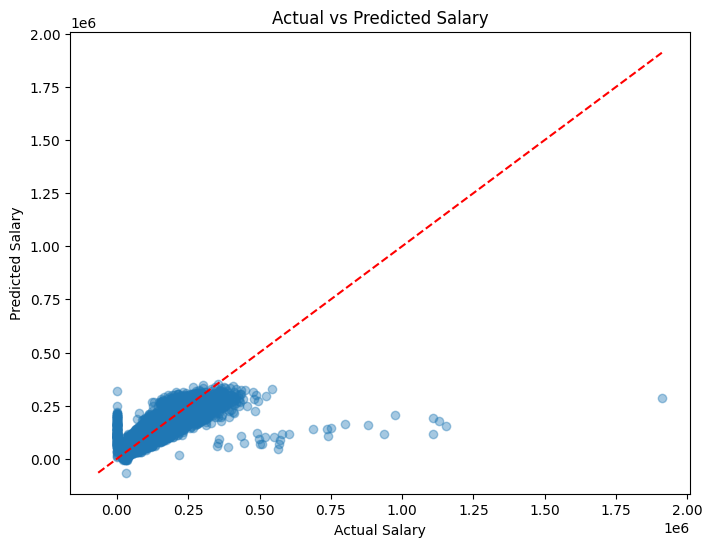

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 23649.06214242155
MSE: 1597537170.9262898
RMSE: 39969.20278071968
R² Score: 0.6575845197617926


## Model Evaluation — Insight

The Linear Regression model gives an MAE of approximately 23,649, which means the predicted salary differs from the actual salary by about 23,649 on average.

The RMSE is approximately 39,969, which indicates that some predictions have larger errors.

The R² score is 0.6576, meaning the model explains about 65.76% of the variation in average salary.

Overall, the model captures a substantial part of the relationship between the selected job features and salary, but some variation remains unexplained.

**Case 2: Predicting Layoffs-Classification**


The objective of this case is to predict whether a job posting is associated with a layoff within 12 months using classification algorithms.

In [ ]:
df['layoff_within_12_months_flag'].value_counts()

,count
layoff_within_12_months_flag,
N,24004
False,23861
0,23767
No,23600
Y,3638
Yes,3627
1,3592
True,3523


In [ ]:
df['layoff_within_12_months_flag'].unique()

array(['N', '0', 'Yes', 'No', 'False', 'Y', 'True', '1'], dtype=object)

# Standardizing the Layoff Target

The layoff target contains different representations such as Yes, Y, True, and 1 for positive cases, and No, N, False, and 0 for negative cases.

These values are standardized into a single binary format:
1 = Layoff
0 = No Layoff

In [ ]:
df['layoff_target'] = df['layoff_within_12_months_flag'].map({
    'Y': 1,
    'Yes': 1,
    'True': 1,
    '1': 1,
    'N': 0,
    'No': 0,
    'False': 0,
    '0': 0
})

df['layoff_target'].value_counts()

/tmp/ipykernel_33629/1286704292.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['layoff_target'] = df['layoff_within_12_months_flag'].map({


,count
layoff_target,
0,95232
1,14380


# Preparing Features and Target

The standardized 'layoff_target' column is used as the target variable.

The original layoff flag and other non-predictive identifier columns are removed from the features.

In [ ]:
y = df['layoff_target']

X = df.drop(columns=[
    'layoff_target',
    'layoff_within_12_months_flag',
    'job_id'
])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (109612, 27)
y shape: (109612,)


In [ ]:
X.isnull().sum()

,0
company_name,0
company_type,0
sector,0
company_size_employees,0
hq_country,0
job_role,0
seniority_level,0
years_experience_min,0
years_experience_max,0
required_tech_stack,0


In [ ]:
# Fill missing values in categorical columns
categorical_cols = X.select_dtypes(include='object').columns

X[categorical_cols] = X[categorical_cols].fillna('Unknown')

In [ ]:
X.isnull().sum()

,0
company_name,0
company_type,0
sector,0
company_size_employees,0
hq_country,0
job_role,0
seniority_level,0
years_experience_min,0
years_experience_max,0
required_tech_stack,0


In [ ]:
# Fill missing values in numerical columns
numerical_cols = X.select_dtypes(exclude='object').columns

X[numerical_cols] = X[numerical_cols].fillna(X[numerical_cols].median())

In [ ]:
X.isnull().sum()

,0
company_name,0
company_type,0
sector,0
company_size_employees,0
hq_country,0
job_role,0
seniority_level,0
years_experience_min,0
years_experience_max,0
required_tech_stack,0


# Encoding Categorical Features

Categorical features are converted into numerical form using One-Hot Encoding so that they can be used by the classification models.

One-Hot Encoding creates separate binary columns for different categories while keeping the original information.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)],remainder='passthrough')

X_encoded = preprocessor.fit_transform(X)

print("Encoded shape:", X_encoded.shape)

Encoded shape: (109612, 37949)


# Train-Test Split

The dataset is divided into 80% training data and 20% testing data.

Stratification is used to maintain a similar proportion of layoff and no-layoff cases in both the training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X_encoded,y, test_size=0.20,random_state=42,stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (87689, 37949)
X_test shape: (21923, 37949)
y_train shape: (87689,)
y_test shape: (21923,)


# Feature Scaling

Feature scaling is applied using StandardScaler so that numerical features are on a similar scale.

The scaler is fitted only on the training data and then used to transform both the training and testing data.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


# Class Balance Check

The class distribution of the layoff target is checked to understand the balance between layoff and no-layoff cases.

If the classes are imbalanced, accuracy alone may not give a complete picture of model performance.

In [ ]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

layoff_target
0    95232
1    14380
Name: count, dtype: int64
layoff_target
0    86.880998
1    13.119002
Name: proportion, dtype: float64


## Class Balance — Insight

The target classes are imbalanced. About 86.88% of the records belong to the No Layoff class, while 13.12% belong to the Layoff class.

Because of this imbalance, accuracy alone may not give a complete picture of model performance.

# Logistic Regression — Mathematical Intuition

Logistic Regression is used for binary classification. It uses the sigmoid function to convert the model output into a probability between 0 and 1.

The model minimizes Log Loss (Binary Cross-Entropy) to make the predicted probabilities close to the actual class labels.

The model parameters are optimized using Gradient Descent, which updates the parameters step by step to reduce the loss.

Unlike Linear Regression, which uses Ordinary Least Squares (OLS) to find coefficients, Logistic Regression is trained using a classification loss function.

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
y_pred_lr = logistic_model.predict(X_test_scaled)

print("Prediction completed.")
print("Number of predictions:", len(y_pred_lr))

Prediction completed.
Number of predictions: 21923


## Logistic Regression — Model Evaluation

The Logistic Regression model is evaluated using accuracy, precision, recall, and F1-score.

A confusion matrix is also used to see the number of correct and incorrect predictions for the Layoff and No Layoff classes.

Accuracy: 0.8136660128632031
Precision: 0.23049487293802942
Recall: 0.17976356050069542
F1 Score: 0.20199257667513187


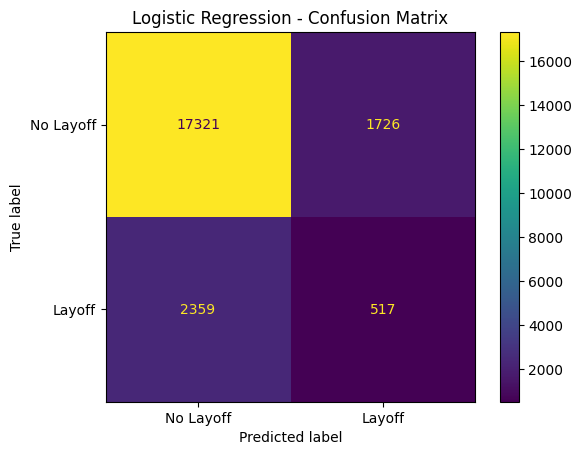

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Layoff", "Layoff")

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## Logistic Regression — Insight

The model achieved an accuracy of about 81.37%, but the precision, recall, and F1-score are much lower.

This indicates that the model has difficulty correctly identifying the Layoff class. Since the dataset is imbalanced, accuracy alone does not fully represent the model's performance.

The confusion matrix shows the correct and incorrect predictions for both No Layoff and Layoff classes.

## Decision Tree — Mathematical Intuition

A Decision Tree makes decisions by splitting the data into smaller groups based on feature values.

It can use Gini Impurity or Entropy to measure how mixed the classes are. The tree selects splits that reduce this impurity.

Unlike Logistic Regression, a Decision Tree does not use Gradient Descent or OLS. It chooses splits based on impurity reduction.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

decision_tree.fit(X_train_scaled, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


In [ ]:
y_pred_dt = decision_tree.predict(X_test_scaled)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)

Accuracy: 0.8685398896136478
Precision: 0.425
Recall: 0.005910987482614743
F1 Score: 0.011659807956104253


In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["No Layoff", "Layoff"]
)

disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()